# Fashion MNIST classification (Keras)

## Libraries and constants

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch
from torch.utils.data import DataLoader, TensorDataset
from utils import seed_everything, plot_loss_acc_per_ep


In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data import

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

## Data Overview

In [4]:
# Train/test sizes
print("\nTrain set: ")
print(X_train.shape)
print(y_train.shape)

print("\nTest set: ")
print(X_test.shape)
print(y_test.shape)


Train set: 
(60000, 28, 28)
(60000,)

Test set: 
(10000, 28, 28)
(10000,)


There are only 3 dimensions (num_images, height, width, 1 color channel) - the images are grayscale.

In [5]:
import numpy as np

np.unique(X_train)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

Each image is a numpy array, unnormalized

Train images:


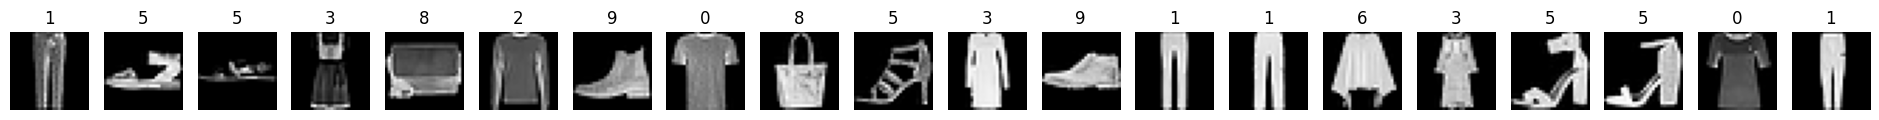

Test images:


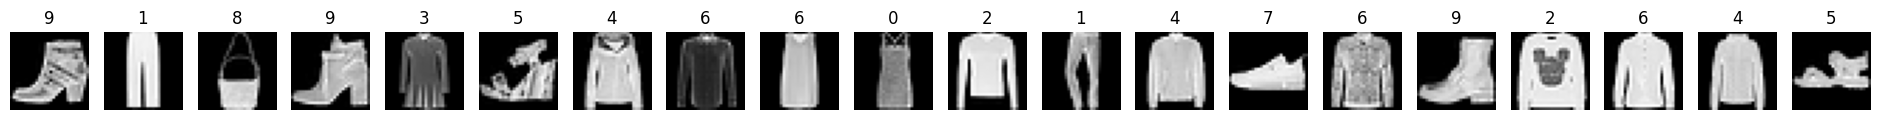

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

def plot_mnist_fashion_images(x_data: np.ndarray, y_data: np.ndarray, num_images: int, rng: np.random.Generator):
    # Select random unique indices using the numpy generator
    random_indices = rng.choice(len(x_data), size=num_images, replace=False)

    # Extract, copy, and cast the randomly sampled data
    np_imgs = x_data[random_indices].copy().astype(np.uint8)  # PIL Image expects uint8
    np_labels = y_data[random_indices].copy()

    plt.figure(figsize=(24, 6))
    for i in range(num_images):
        img = Image.fromarray(np_imgs[i], mode="L")               # to PIL grayscale image
        label = np_labels[i]

        plt.subplot(
                1,              # a number of rows to plot on
                num_images,     # a number of columns
                i + 1,          # current position to plot in
            )
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

print("Train images:")
plot_mnist_fashion_images(X_train, y_train, 20, rng)

print("Test images:")
plot_mnist_fashion_images(X_test, y_test, 20, rng)

In [7]:
print(f"Train targets: {np.unique(y_train)}")
print(f"Test targets: {np.unique(y_test)}")

Train targets: [0 1 2 3 4 5 6 7 8 9]
Test targets: [0 1 2 3 4 5 6 7 8 9]


Each image represents a fashion item 28x28. The target labels are 10 categorical integers (0-9).

### Class balance

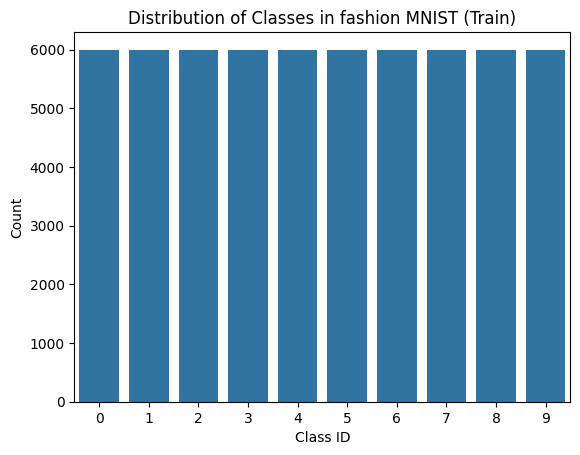

In [8]:
import seaborn as sns

sns.countplot(x=y_train)
plt.title("Distribution of Classes in fashion MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [9]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

The train set is perfectly distributed. No imbalance concerns.

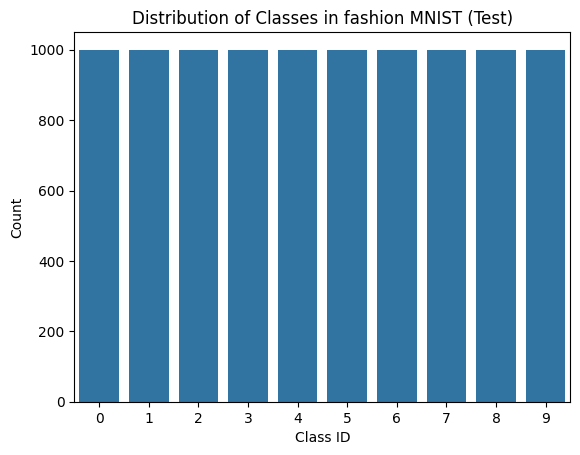

In [10]:
sns.countplot(x=y_test)
plt.title("Distribution of Classes in fashion MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [11]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000],
       dtype=int64))

The test set is perfectly distributed. No imbalance concerns.

### Data representation

The dataset is light and easy, but if we were to face a real problem with huge data that doesn't fit RAM, we would have to move away from np arrays completely. We're going to do it this way.

In [12]:
# 1. Create standard PyTorch streaming loader
# for simple data just:
# torch_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))

from torch.utils.data import DataLoader, Dataset, Subset, random_split

class FashionMNISTDataset(Dataset):
    def __init__(self, data: np.ndarray, targets: np.ndarray):
        self.data = torch.from_numpy(data).clone().float()
        self.targets = torch.from_numpy(targets).clone().int()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        return img, target

In [13]:
X_train_writable = X_train.copy()

full_train_ds  = FashionMNISTDataset(X_train_writable, y_train)
test_ds  = FashionMNISTDataset(X_test, y_test)

# Split train into train/validation (90/10)
train_size = int(0.9 * len(X_train))
val_size = len(full_train_ds) - train_size

train_ds, valid_ds = random_split(
    dataset=full_train_ds,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_7864\2997815180.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  self.targets = torch.from_numpy(targets).clone().int()


Confirming everything's intact.

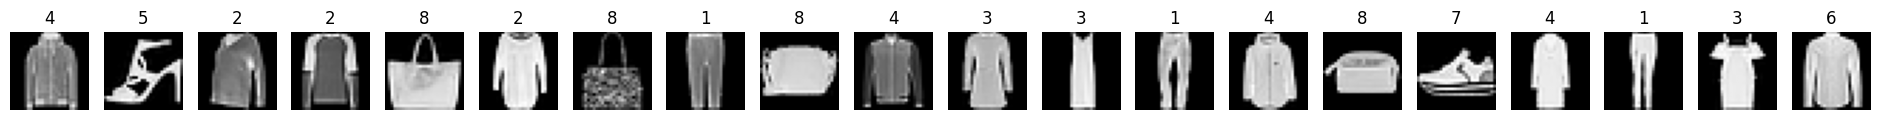

In [14]:
plot_mnist_fashion_images(full_train_ds.data.numpy(), full_train_ds.targets.numpy(), 20, rng)

In [15]:
print(f"Train: {len(train_ds)}, Validation: {len(valid_ds)}, Test: {len(test_ds)}")

Train: 54000, Validation: 6000, Test: 10000


In [16]:
img, label = train_ds[0]
print(img.shape, label)

torch.Size([28, 28]) tensor(9, dtype=torch.int32)


## Creating and testing loaders

In [17]:
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, generator=torch_gen)
valid_loader = DataLoader(valid_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

In [18]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([1024, 28, 28])
Targets batch shape: torch.Size([1024])
Images data type   : torch.float32
Targets data type  : torch.int32
Targets in batch   : tensor([9, 3, 3,  ..., 3, 6, 6], dtype=torch.int32)


## EDA

### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

In [19]:
# (60000, 28, 28) -> (60000, 784)
train_images_2d = X_train.reshape(-1, 784)

print(f"mnist_train_array_2d.shape = {train_images_2d.shape}")

mnist_train_array_2d.shape = (60000, 784)


In [20]:
from sklearn.ensemble import IsolationForest

# ---------- STEP 1: Fit ----------
iso = IsolationForest(
    n_estimators=500,           # number of random trees
    contamination=0.01,         # expect ~1% anomalies
    max_samples='auto',         # subsample size per tree
    random_state=RANDOM_SEED,
)

iso.fit(train_images_2d)

,n_estimators,500
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [21]:
# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) ----------
flags = iso.predict(train_images_2d)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

Train anomalies flagged: 600


In [22]:
# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(train_images_2d)
print("Top 5 lowest (most anomalous) scores:", sorted(anomaly_score)[:5])

Top 5 lowest (most anomalous) scores: [-0.6934106527099005, -0.6659250893274931, -0.6656201525195374, -0.6626475185657702, -0.662274318689953]


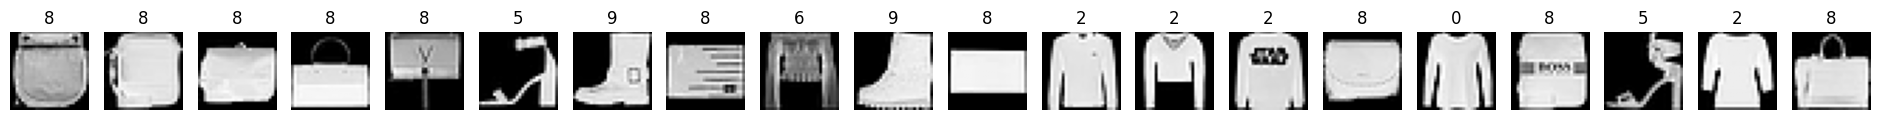

In [23]:
# ---------- STEP 4: See the flagged images ----------
outlier_idx = np.where(flags == -1)[0]
outliers_mnist_train = np.array([X_train[idx] for idx in outlier_idx])
outlier_targets = np.array([y_train[idx] for idx in outlier_idx])

plot_mnist_fashion_images(outliers_mnist_train, outlier_targets, 20, rng)

All items are recognizable, some corners are cut, noisy backgrounds, even in the worst-flagged images. No outliers present. To fully confirm we do indeed have only the 10 mentioned classes, we'd have to obtain more data. There's not enough evidence to say no side objects present as if the nature of their pixels is similar to our data, Isolation Forest can't discern them.

We cannot mathematically prove there are exactly zero out-of-class items in a 60,000-image dataset unless we look at all 60,000. Instead, we must define a tiny acceptable error threshold. For data science, a standard threshold is fewer than 1% of the data being corrupted/out-of-class. We are going to use Acceptance Sampling.

**The goal**: We want to be 95% confident that the out-of-class rate in the dataset is under 1%.
$H_0$: The dataset **DOES** contain unrelated images. The proportion of unrelated images $p ≥ 0.01$
$H_1$: The dataset **DOES NOT** contain unrelated images. - The proportion of unrelated images $p < 0.01$.

If the true rate of bad images is $1\%$ ($0.01$), then the probability of a randomly picked image being *correct* (fashion) is $99\%$ ($0.99$) each. For a sample size of $n$, the probability of picking $n$ correct images in a row is the product (1st AND 2nd AND 3rd ...): $$p = (0.99)^n \leftarrow \text{Probability of 0 defects}$$
Now, we demand based on the condition and solve:

$$\begin{gather*}
(0.99)^n \le 0.05 \\ \\
\text{Solving for $n$ using logarithms:} \\
\ln(0.99)^n \le \ln(0.05) \\
n \cdot \ln(0.99) \le \ln(0.05) \\
n \ge \frac{\ln(0.05)}{\ln(0.99)} \\ \\
\text{Plug in the values:} \\
n \ge \frac{-2.9957}{-0.01005} \approx 298.07 
\end{gather*}$$

*Decision*: To prove with $95\%$ confidence that the dataset has less than $1\%$ unrelated images, we must **randomly sample and inspect $299$ images**. 
- If we find $0$ unrelated images, we reject $H_0$ and may state with $95\%$ confidence that the overall defect rate is $< 1\%$. > 
- If we find even $1$ unrelated image, we fail to reject $H_0$ and therefore cannot guarantee that the defect rate is below $1\%$.

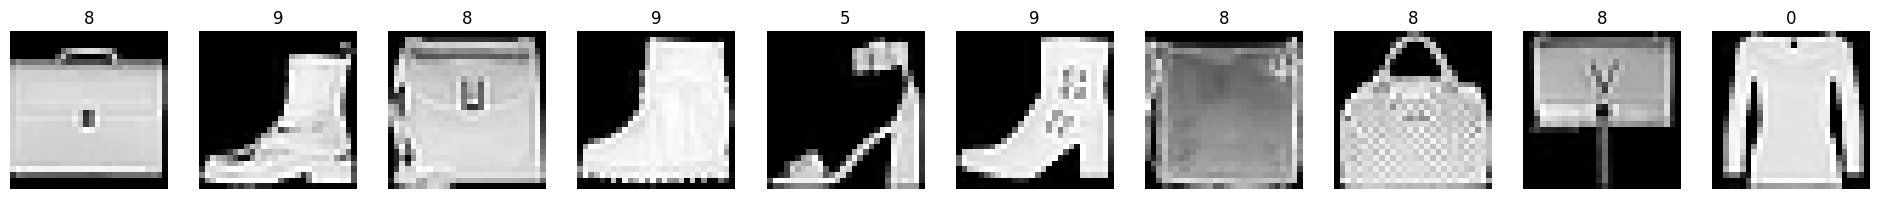

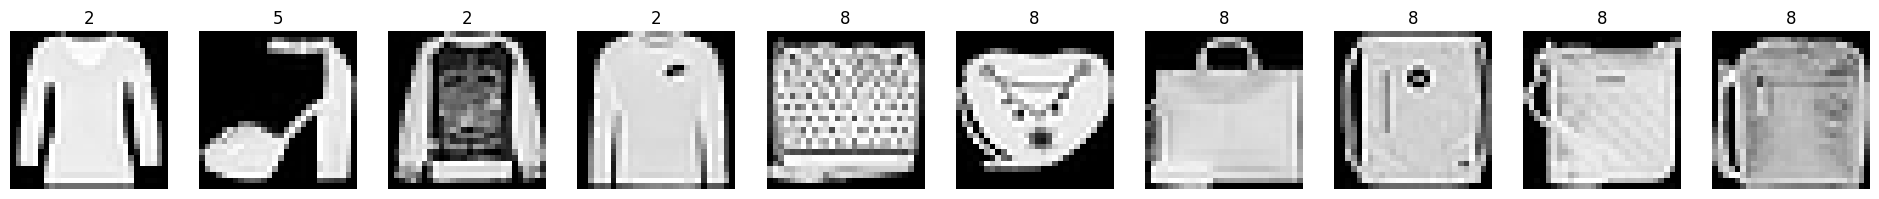

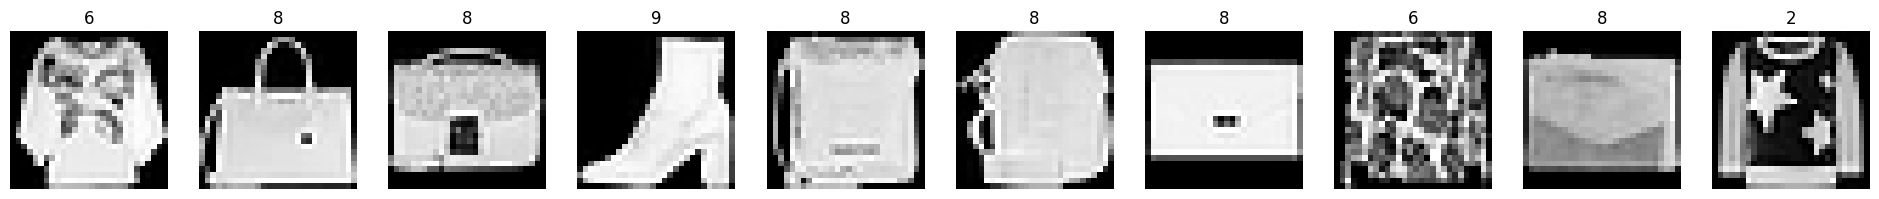

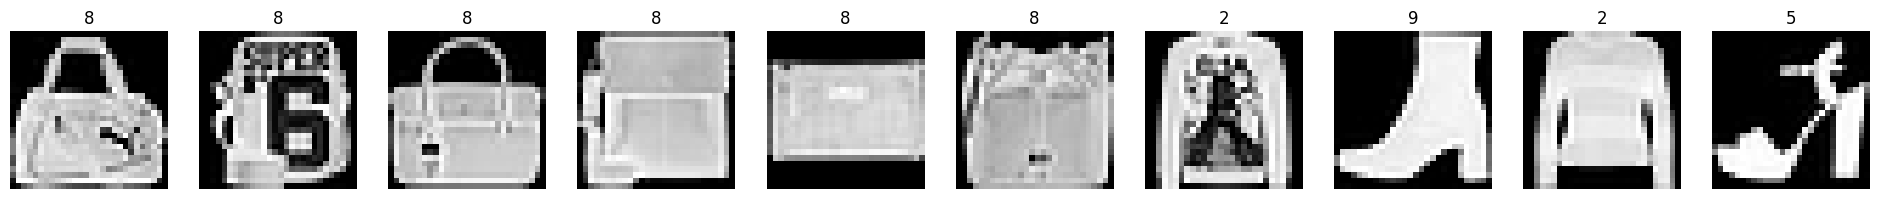

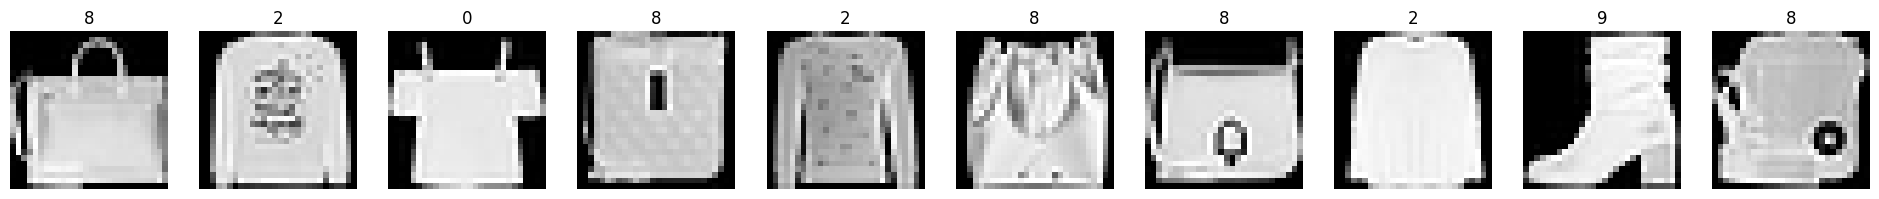

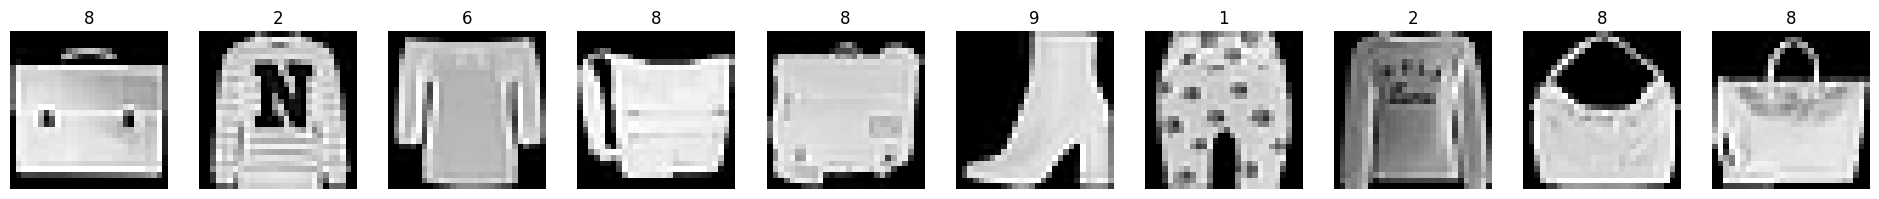

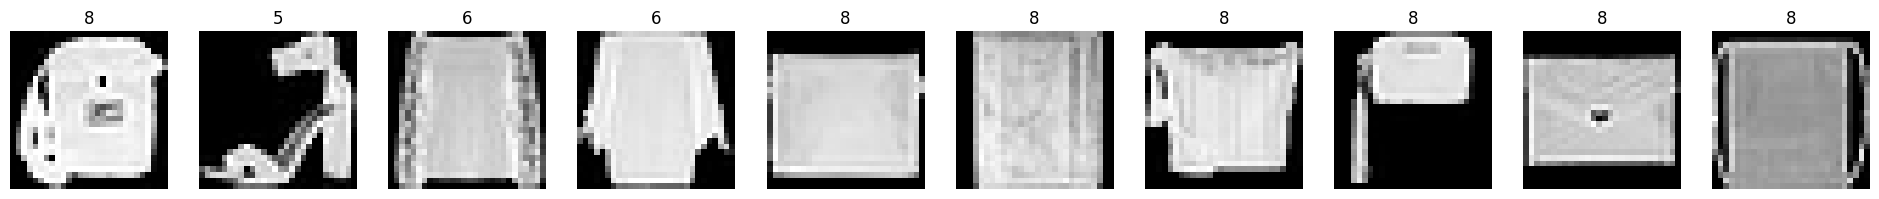

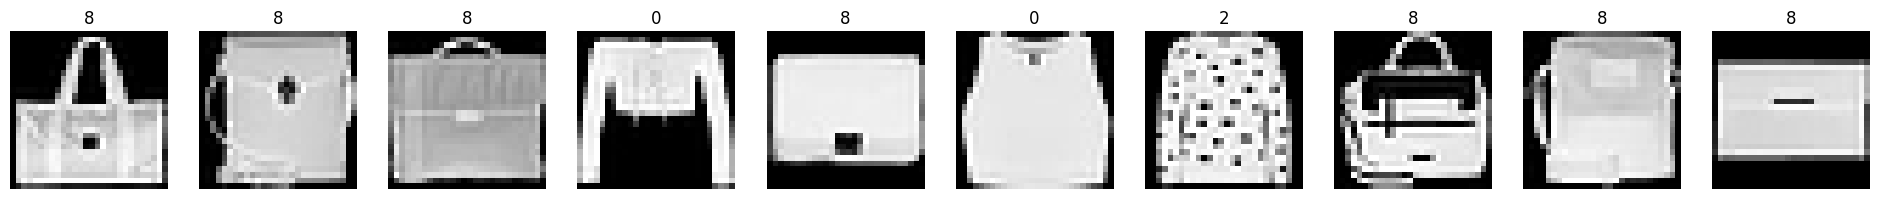

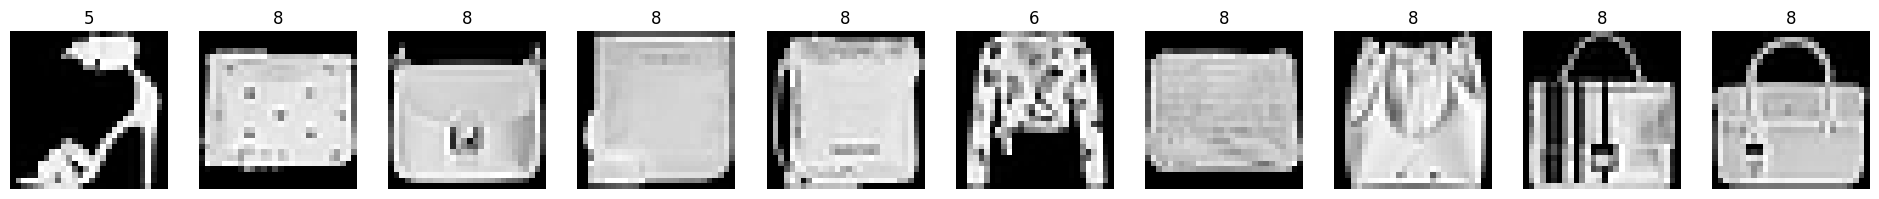

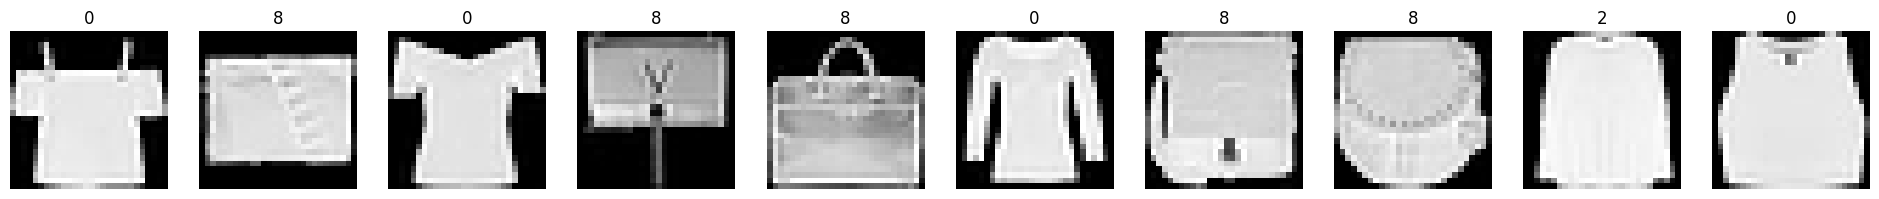

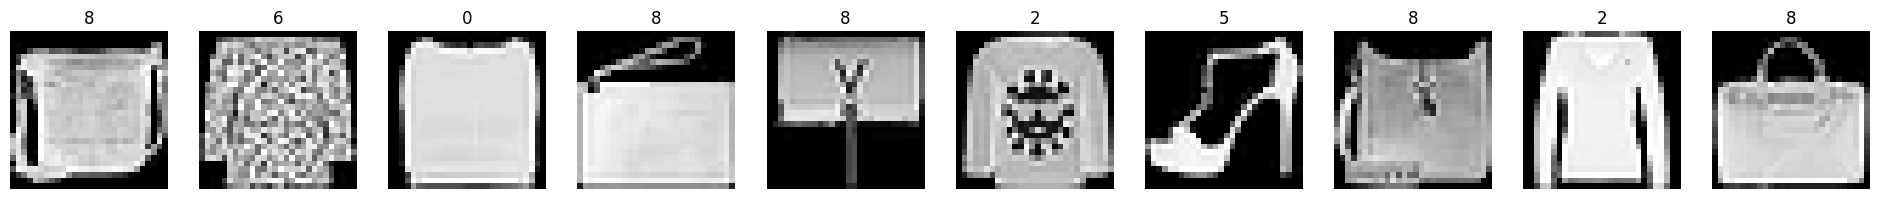

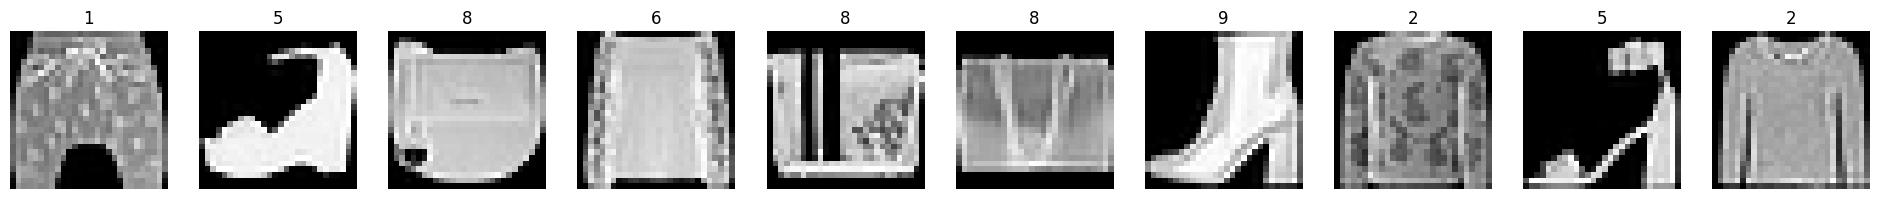

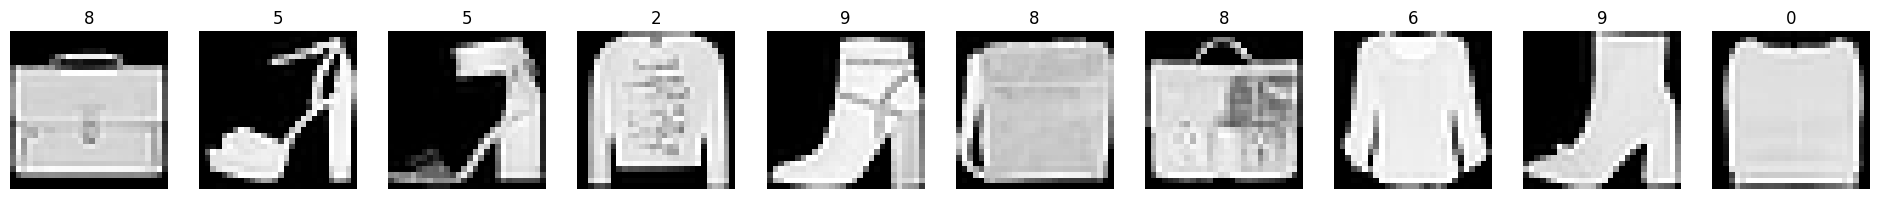

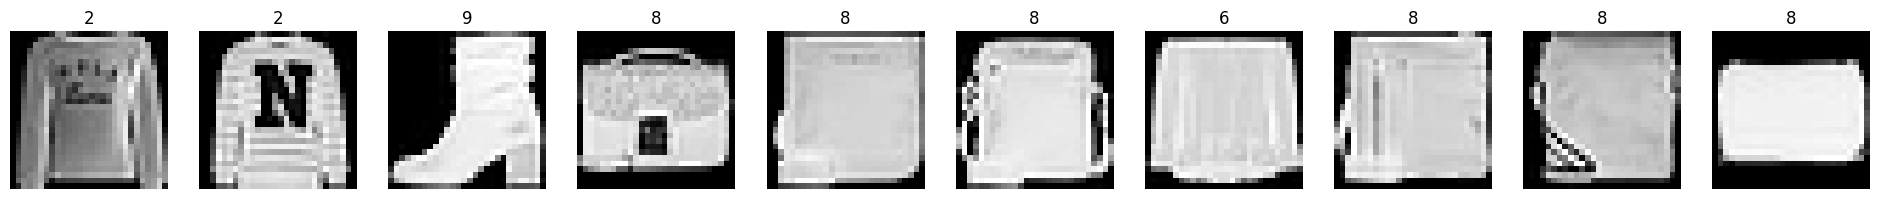

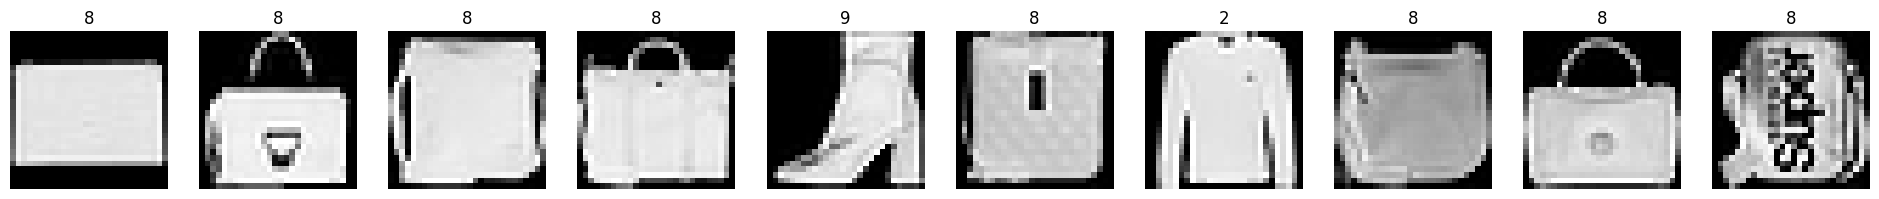

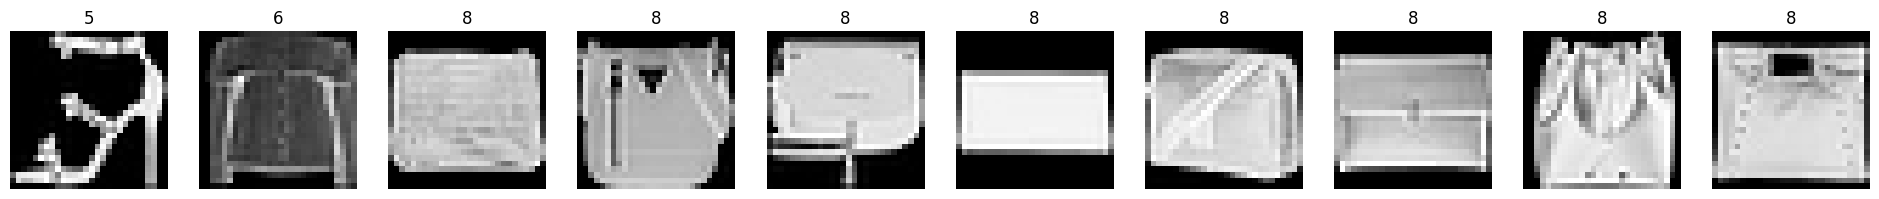

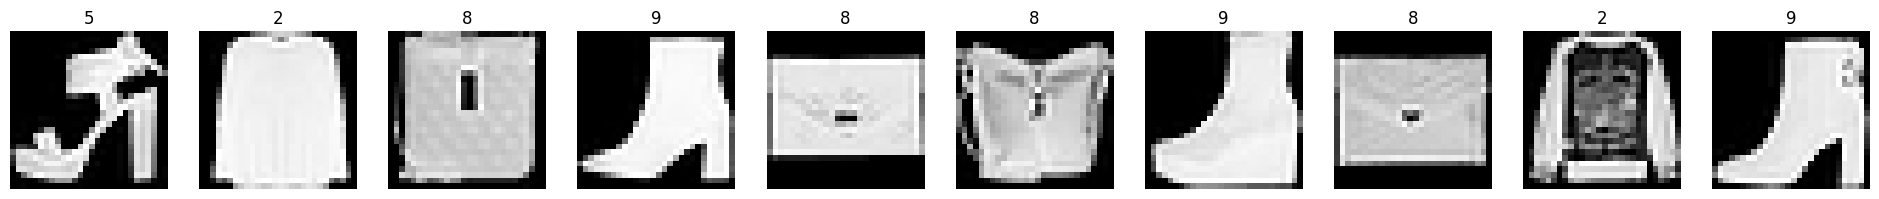

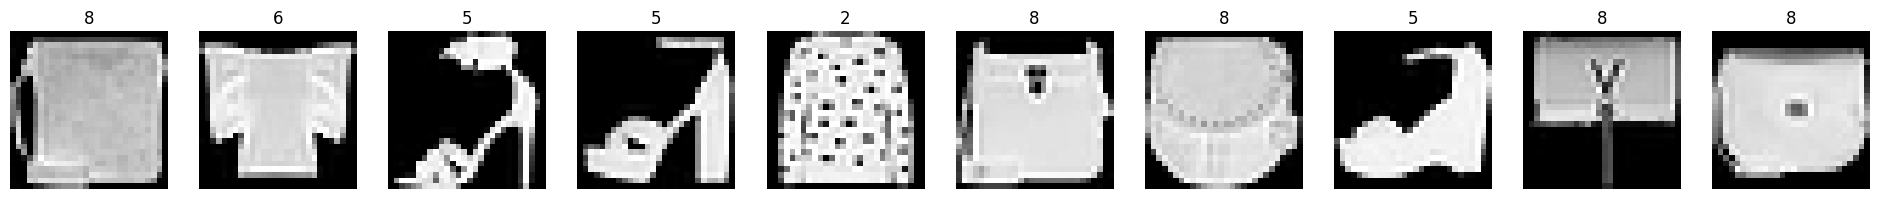

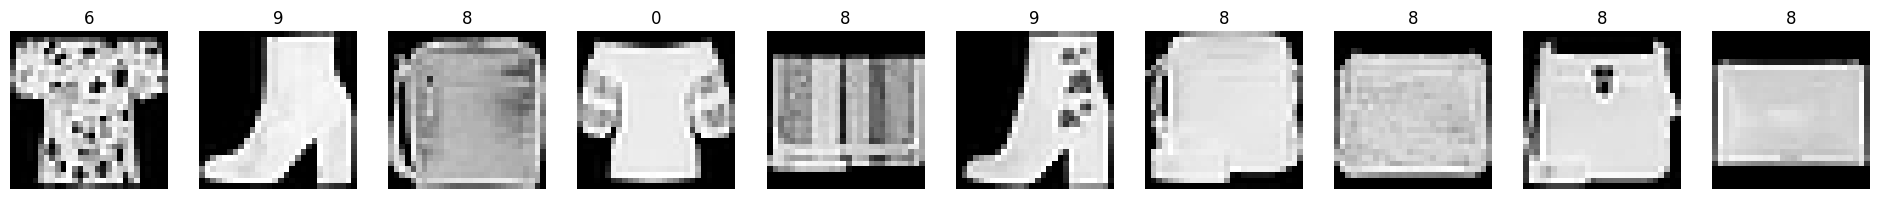

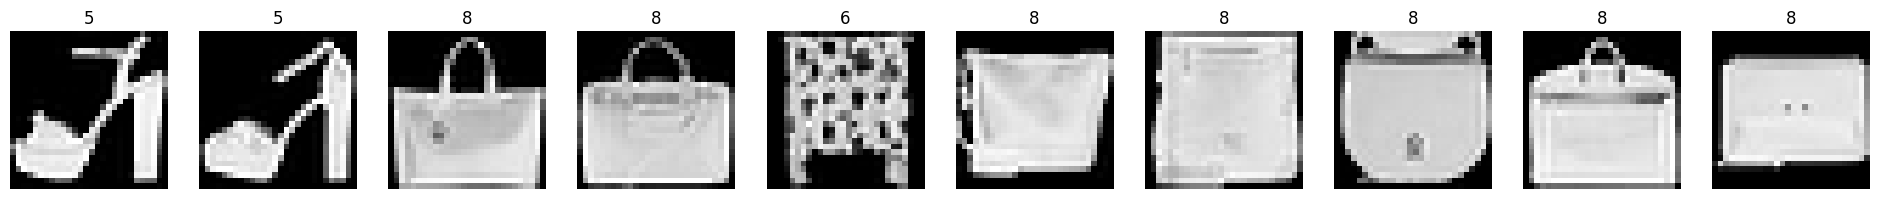

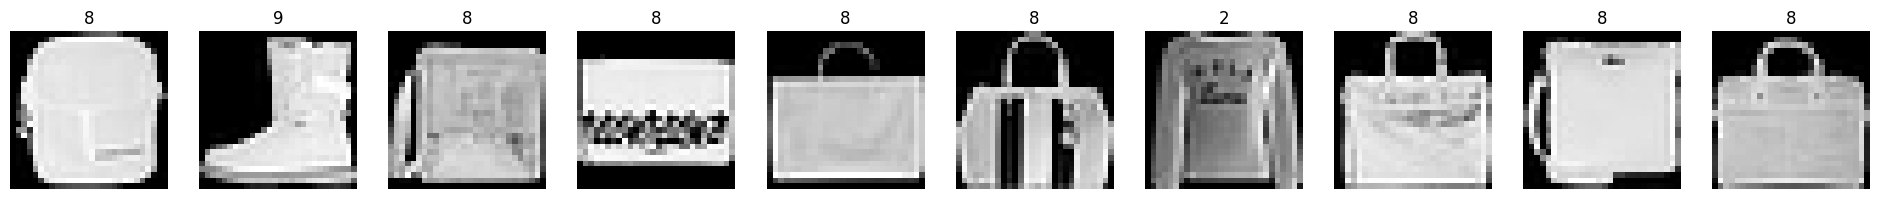

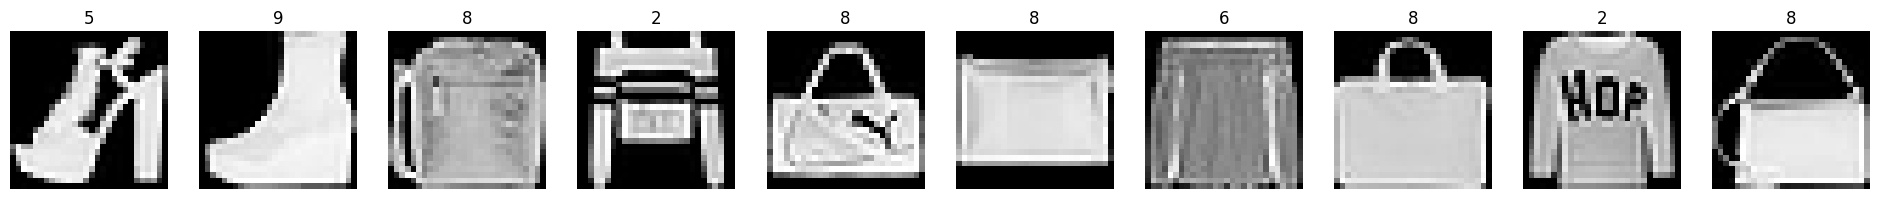

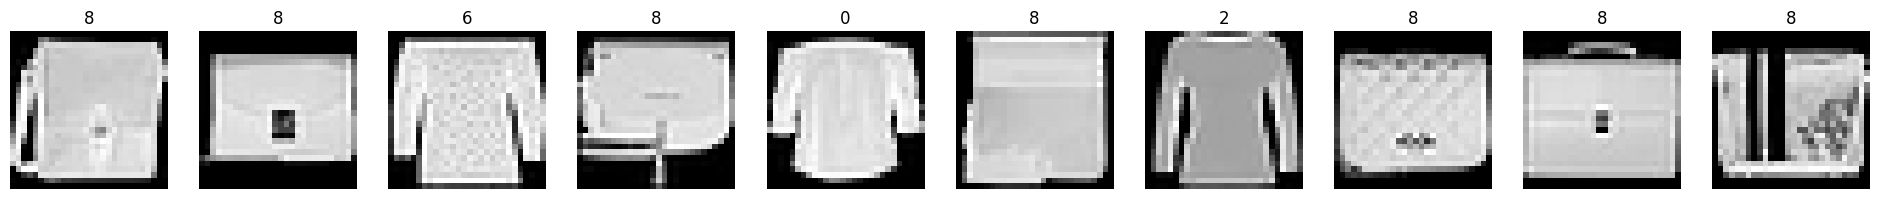

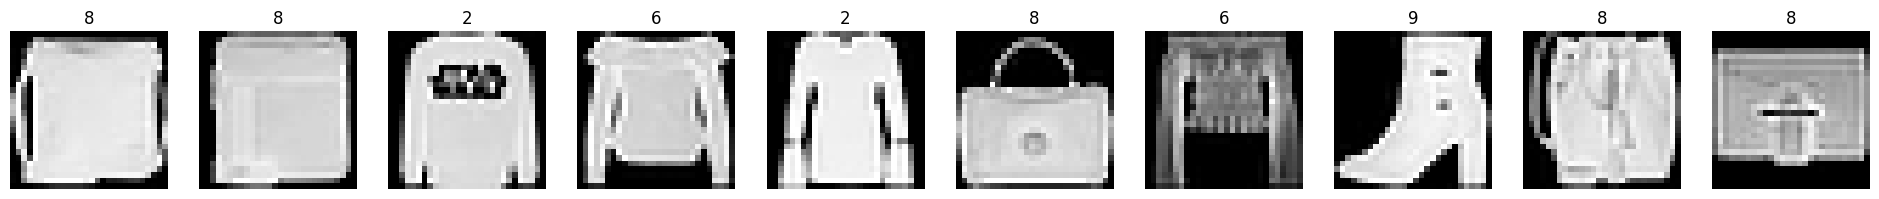

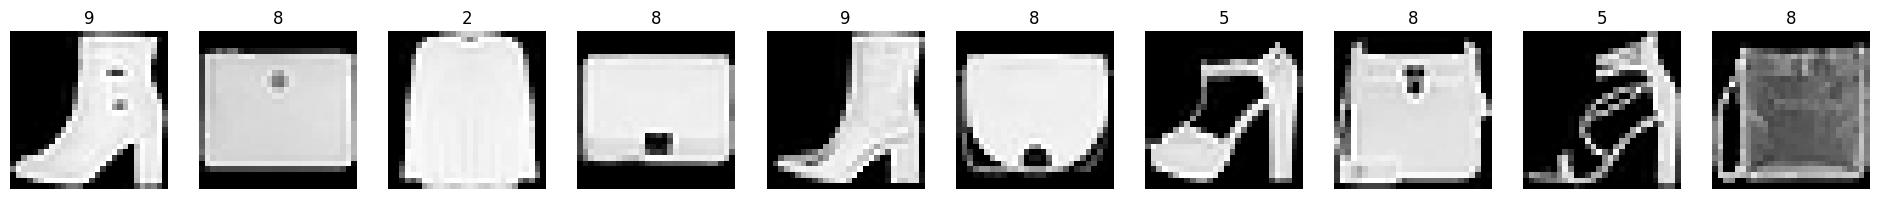

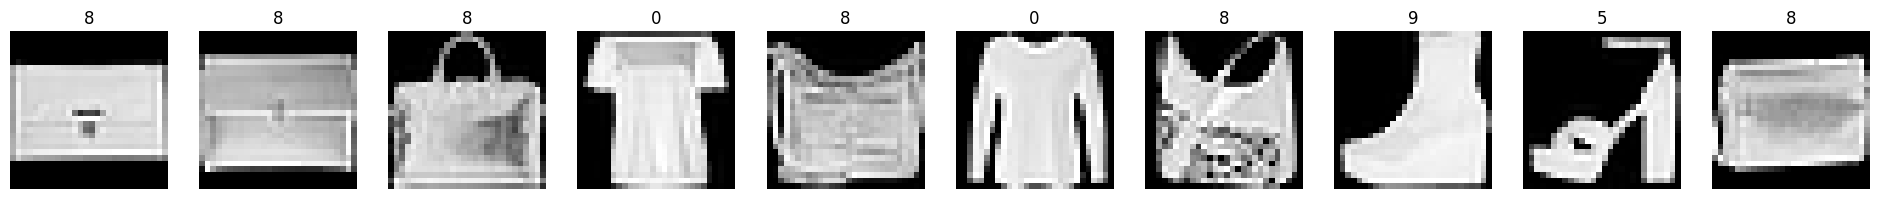

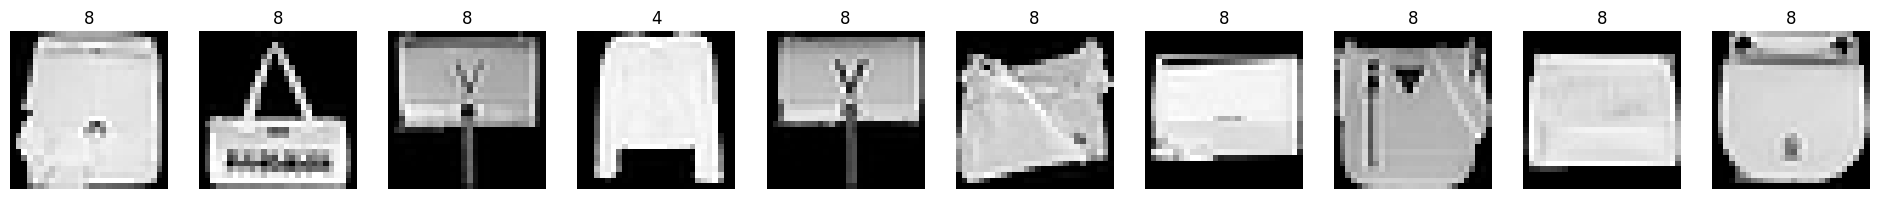

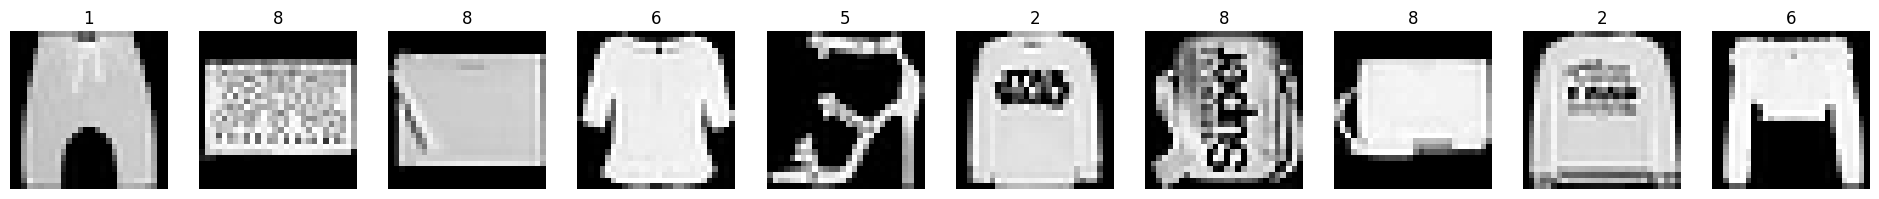

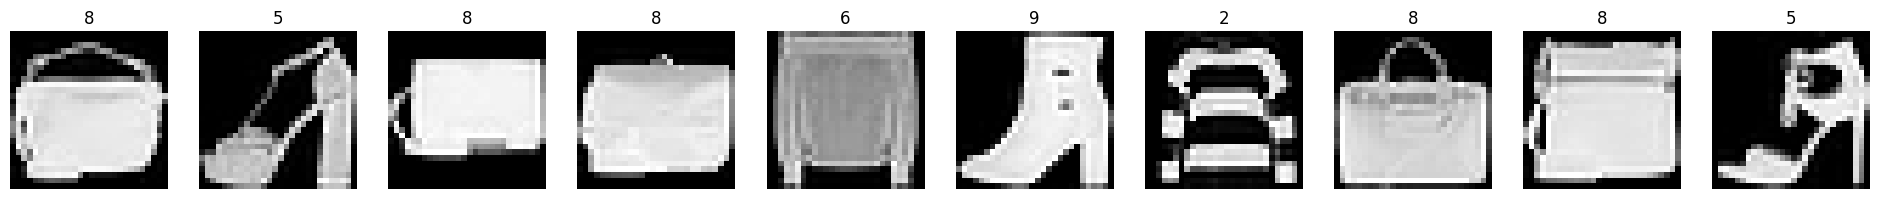

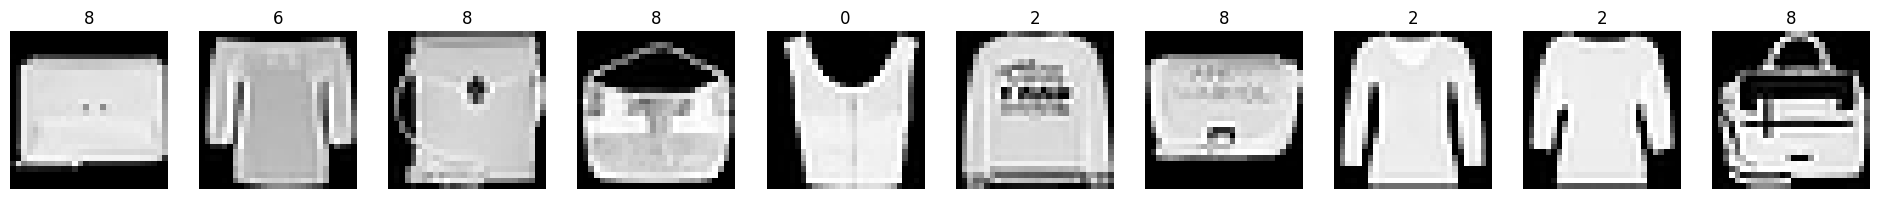

In [24]:
for i in range(30):
    plot_mnist_fashion_images(outliers_mnist_train, outlier_targets, 10, rng)

No out-of-class images found. The $H_0$ rejected.

## Model, metric and hyperparameter selection

Based on the fact that the task is a literal substitute for standard MNIST, we presume minimal complexity is necessary. We are going to utilize the same FFN network, just adding Dropout with low probability for educational purposes and mimic biology closer.

As for the metrics, we choose accuracy because the set is perfectly balanced while still tracking macro f1 as a matter of respect to the real world data, planning to conclude using the full classification report.

For the loss function - cross-entropy - the undisputed, industry-wide mathematical standard for multiclass classification.

Optimizer - Adam - also industry standard with relatively high learning rate of 1e-3. We will be tunning with other optimizers as well. This is a strong baseline.

In [25]:
model = keras.Sequential([
    # Explicitly define the input shape as its own layer object (best practice)
    keras.layers.Input(shape=(28, 28)),
    #normalizer,
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Data normalization

As always, for the sake of speeding up the convergence, stabilize GD, eliminating brightness  biases, we normalize the pixel data to $[0,1]$, then standardize features to a sample mean of $\mu=0$ and sample standard deviation of $s=0$.

In order to do that, we need the whole dataset, which in this case is not huge and fits RAM. But the best practice is to import it in batches in case there are too many samples.

While importing, we're summing the sums and elements to later calculate final dataset's mean and std to use them for z-normalization.

In [26]:
# Calculate the whole dataset's mean and std
n = 0; s = 0.0; ss = 0.0
for x, _ in train_loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()

mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5
variance_ds = std_ds ** 2

# Hardcode the stats into Keras
normalizer = keras.layers.Normalization(
    axis=None,
    mean=mean_ds,
    variance=variance_ds,
)

The model now:

In [ ]:
def build_baseline_model(num_units=128, dropout=0.1, lr=1e-3, activation="relu", random_seed: int = 42):
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
        keras.layers.Dense(num_units, activation=activation),
        keras.layers.Dropout(dropout, seed=random_seed),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader, test_loader

## Training

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)      # seeds python/numpy/torch/keras in one call
torch_gen.manual_seed(RANDOM_SEED)            # rewind the generator's state

train_loader, valid_loader, test_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)
model = build_baseline_model(num_units=128, dropout=0.1, lr=1e-3, activation="relu", random_seed=RANDOM_SEED)

history = model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8168 - loss: 0.5165 - val_accuracy: 0.8562 - val_loss: 0.3923
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8630 - loss: 0.3752 - val_accuracy: 0.8672 - val_loss: 0.3697
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8746 - loss: 0.3424 - val_accuracy: 0.8752 - val_loss: 0.3520
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8828 - loss: 0.3211 - val_accuracy: 0.8787 - val_loss: 0.3380
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8889 - loss: 0.3010 - val_accuracy: 0.8765 - val_loss: 0.3415
Epoch 6/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8932 - loss: 0.2866 - val_accuracy: 0.8823 - val_loss: 0.3265
Epoch 7/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8968 - loss: 0.2761 - val_accuracy: 0.8848 - val_loss: 0.3159
Epoch 8/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9028 - loss: 0.2639 - val_accu

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.5165  val_loss=0.3923  train_acc=0.8168  val_acc=0.8562
Epoch  2: train_loss=0.3752  val_loss=0.3697  train_acc=0.8630  val_acc=0.8672
Epoch  3: train_loss=0.3424  val_loss=0.3520  train_acc=0.8746  val_acc=0.8752
Epoch  4: train_loss=0.3211  val_loss=0.3380  train_acc=0.8828  val_acc=0.8787
Epoch  5: train_loss=0.3010  val_loss=0.3415  train_acc=0.8889  val_acc=0.8765
Epoch  6: train_loss=0.2866  val_loss=0.3265  train_acc=0.8932  val_acc=0.8823
Epoch  7: train_loss=0.2761  val_loss=0.3159  train_acc=0.8968  val_acc=0.8848
Epoch  8: train_loss=0.2639  val_loss=0.3186  train_acc=0.9028  val_acc=0.8870
Epoch  9: train_loss=0.2569  val_loss=0.3329  train_acc=0.9052  val_acc=0.8817
Epoch 10: train_loss=0.2485  val_loss=0.3116  train_acc=0.9075  val_acc=0.8860
Epoch 11: train_loss=0.2406  val_loss=0.3224  train_acc=0.9101  val_acc=0.8873
Epoch 12: train_loss=0.2295  val_loss=0.3169  train_acc=0.9139  val_acc=0.8880
Epoch 1

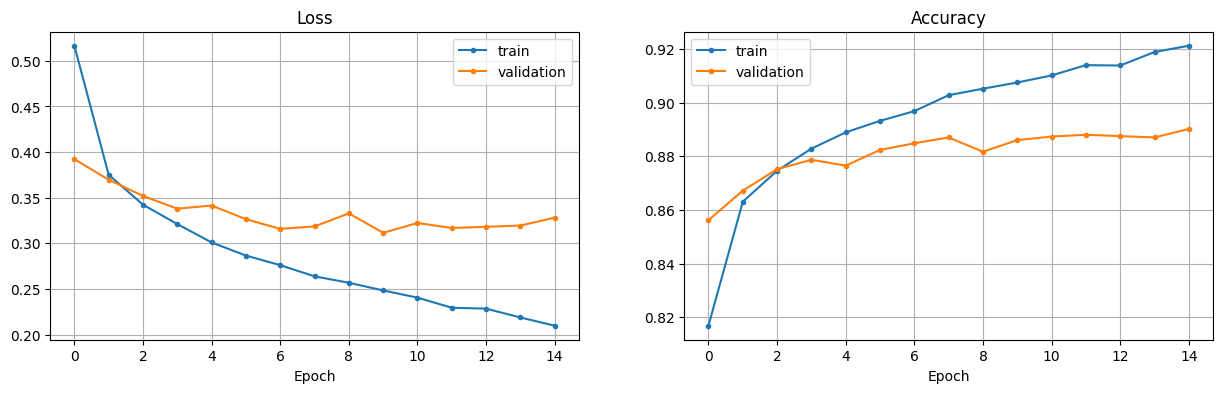

In [39]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])

Baseline best:

| Epoch (Best) | Batch Size | Optimizer, LR          | Train Loss | Val Loss | Train Acc | Val Acc |
| :---:        | :---:      | :---:                  | :---:      | :---:    | :---:     | :---:   |
| 4            | 125        | Adam(1e-3)             | 0.3211     | 0.3380   | 0.8828    | 0.8787  |

Looks like it might need a LR scheduler since after arriving near the minimum it might be taking too aggressive leaps forward.

**Strategy**: before applying LR schedulers, I suppose it might be a good idea to arrive at the most possible point initially.  

In [60]:
3*4*3*4*4*3

1728

In [78]:
import keras_tuner as kt


def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256
    activation = hp.Choice("activation", ["relu", "tanh", "elu"])       # relu,tanh,elu
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # 0.0,0.1,0.2,0.3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation=activation))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



keras.utils.set_random_seed(RANDOM_SEED)         # weight init / dropout inside every trial
torch_gen.manual_seed(RANDOM_SEED)               # rewind the loader generator
train_loader, valid_loader, test_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,                # keyword, not positional
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 01m 17s]
val_accuracy: 0.8833333253860474

Best val_accuracy So Far: 0.8918333053588867
Total elapsed time: 00h 16m 45s
{'num_layers': 1, 'units': 256, 'activation': 'elu', 'dropout': 0.2, 'lr': 0.001, 'optimizer': 'adam'}


In [79]:
import pandas as pd


def debug_tuner(tuner):
    trial_list = []

    # Loop through all trials stored in the tuner's oracle
    for trial_id, trial in tuner.oracle.trials.items():
        row = {
            "trial_id": trial_id,
            "score": trial.score,  # This will be your val_accuracy or val_loss
        }
        # Unpack and add the specific hyperparameters chosen for this trial
        row.update(trial.hyperparameters.values)
        trial_list.append(row)

    # Convert to DataFrame
    df_results = pd.DataFrame(trial_list)

    # Sort them so the best-performing models are at the top
    # (Change ascending=True if you are optimizing for loss instead of accuracy)
    df_results = df_results.sort_values(by="score", ascending=False)

    # Display the neat table!
    display(df_results.head(15))

In [80]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,activation,dropout,lr,optimizer
9,09,0.891833,1,256,elu,0.2,0.0010,adam
11,11,0.888500,1,256,elu,0.0,0.0010,rmsprop
4,04,0.886500,1,128,elu,0.1,0.0005,rmsprop
13,13,0.885167,2,64,elu,0.1,0.0010,adam
6,06,0.885000,3,64,elu,0.0,0.0005,adam
14,14,0.883333,2,128,tanh,0.2,0.0010,adam
1,01,0.882833,3,64,elu,0.0,0.0010,adam
10,10,0.882333,1,128,elu,0.2,0.0005,adam
3,03,0.878000,1,64,elu,0.2,0.0050,adam
0,00,0.877500,2,64,tanh,0.0,0.0050,sgd


Most of the time, the prevalent parameters among the best scores are: Adam, elu. Hold these constant and running again:

In [81]:
3*4*4*4

192

In [82]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    units = hp.Int("units", min_value=64, max_value=256, step=64)       # 64,128,192,256
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # 0.0,0.1,0.2,0.3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=units, activation="elu"))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



keras.utils.set_random_seed(RANDOM_SEED)         # weight init / dropout inside every trial
torch_gen.manual_seed(RANDOM_SEED)               # rewind the loader generator
train_loader, valid_loader, test_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,                # keyword, not positional
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 01m 10s]
val_accuracy: 0.8865000009536743

Best val_accuracy So Far: 0.8934999704360962
Total elapsed time: 00h 17m 57s
{'num_layers': 3, 'units': 128, 'dropout': 0.0, 'lr': 0.0005}


In [83]:
debug_tuner(tuner)

,trial_id,score,num_layers,units,dropout,lr
7,07,0.893500,3,128,0.0,0.0005
5,05,0.888833,3,128,0.1,0.0005
4,04,0.886500,2,64,0.0,0.0005
14,14,0.886500,2,128,0.0,0.0010
9,09,0.885167,3,64,0.0,0.0010
0,00,0.885000,2,64,0.1,0.0005
2,02,0.884500,2,64,0.2,0.0010
6,06,0.883500,1,64,0.2,0.0010
13,13,0.877833,2,256,0.1,0.0001
1,01,0.876667,3,128,0.1,0.0001


In [65]:
import pandas as pd

trial_list = []

# Loop through all trials stored in the tuner's oracle
for trial_id, trial in tuner.oracle.trials.items():
    row = {
        "trial_id": trial_id,
        "status": trial.status,
        "score": trial.score,  # This will be your val_accuracy or val_loss
    }
    # Unpack and add the specific hyperparameters chosen for this trial
    row.update(trial.hyperparameters.values)
    trial_list.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(trial_list)

# Sort them so the best-performing models are at the top
# (Change ascending=True if you are optimizing for loss instead of accuracy)
df_results = df_results.sort_values(by="score", ascending=False)

# Display the neat table!
df_results.head(15)

,trial_id,status,score,num_layers,units,activation,dropout,lr,optimizer
9,09,COMPLETED,0.891833,1,256,elu,0.2,0.0010,adam
11,11,COMPLETED,0.888500,1,256,elu,0.0,0.0010,rmsprop
4,04,COMPLETED,0.886500,1,128,elu,0.1,0.0005,rmsprop
13,13,COMPLETED,0.885167,2,64,elu,0.1,0.0010,adam
6,06,COMPLETED,0.885000,3,64,elu,0.0,0.0005,adam
14,14,COMPLETED,0.883333,2,128,tanh,0.2,0.0010,adam
1,01,COMPLETED,0.882833,3,64,elu,0.0,0.0010,adam
10,10,COMPLETED,0.882333,1,128,elu,0.2,0.0005,adam
3,03,COMPLETED,0.878000,1,64,elu,0.2,0.0050,adam
0,00,COMPLETED,0.877500,2,64,tanh,0.0,0.0050,sgd


In [66]:
3*4*4

48

In [ ]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)                   # 0.0,0.1,0.2,0.3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=256, activation="elu"))
        model.add(keras.layers.Dropout(dropout, seed=RANDOM_SEED))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)         # weight init / dropout inside every trial
torch_gen.manual_seed(RANDOM_SEED)               # rewind the loader generator
train_loader, valid_loader, test_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=15,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,                # keyword, not positional
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 15 Complete [00h 00m 35s]
val_accuracy: 0.8840000033378601

Best val_accuracy So Far: 0.8941666483879089
Total elapsed time: 00h 10m 48s
{'num_layers': 2, 'dropout': 0.0, 'lr': 0.0005}


In [68]:
trial_list = []

# Loop through all trials stored in the tuner's oracle
for trial_id, trial in tuner.oracle.trials.items():
    row = {
        "trial_id": trial_id,
        "status": trial.status,
        "score": trial.score,  # This will be your val_accuracy or val_loss
    }
    # Unpack and add the specific hyperparameters chosen for this trial
    row.update(trial.hyperparameters.values)
    trial_list.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(trial_list)

# Sort them so the best-performing models are at the top
# (Change ascending=True if you are optimizing for loss instead of accuracy)
df_results = df_results.sort_values(by="score", ascending=False)

# Display the neat table!
df_results.head(15)

,trial_id,status,score,num_layers,dropout,lr
0,00,COMPLETED,0.894167,2,0.0,0.0005
12,12,COMPLETED,0.892667,1,0.0,0.0005
2,02,COMPLETED,0.892500,1,0.2,0.0010
6,06,COMPLETED,0.891500,2,0.1,0.0005
11,11,COMPLETED,0.890667,3,0.0,0.0005
8,08,COMPLETED,0.889833,3,0.2,0.0005
1,01,COMPLETED,0.886667,1,0.2,0.0005
14,14,COMPLETED,0.884000,2,0.0,0.0010
4,04,COMPLETED,0.875667,1,0.1,0.0001
7,07,COMPLETED,0.873500,1,0.0,0.0010


Further shrinking the search space: dropout=0.0

In [69]:
def build_rand_search_model(hp):
    # model header
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        normalizer,
        keras.layers.Flatten(),
    ])

    # Define the hyperparameters
    num_layers = hp.Int("num_layers", min_value=1, max_value=3)         # 1,2,3

    for _ in range(num_layers):
        model.add(keras.layers.Dense(units=256, activation="elu"))

    model.add(keras.layers.Dense(10, activation="softmax"))

    lr = hp.Choice("lr", values=[0.0001, 0.0005, 0.001, 0.005])
    optimizer_obj = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer_obj,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


keras.utils.set_random_seed(RANDOM_SEED)         # weight init / dropout inside every trial
torch_gen.manual_seed(RANDOM_SEED)               # rewind the loader generator
train_loader, valid_loader, test_loader = build_loaders(batch_size=125, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_model,
    objective="val_accuracy",
    max_trials=12,
    directory="tuning",
    project_name="fashion_mnist",
    seed=RANDOM_SEED,                           # which HP combos get sampled
    overwrite=True,                             # start fresh every trial
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,                # keyword, not positional
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 12 Complete [00h 00m 33s]
val_accuracy: 0.89083331823349

Best val_accuracy So Far: 0.8931666612625122
Total elapsed time: 00h 09m 51s
{'num_layers': 1, 'lr': 0.001}


In [70]:
trial_list = []

# Loop through all trials stored in the tuner's oracle
for trial_id, trial in tuner.oracle.trials.items():
    row = {
        "trial_id": trial_id,
        "status": trial.status,
        "score": trial.score,  # This will be your val_accuracy or val_loss
    }
    # Unpack and add the specific hyperparameters chosen for this trial
    row.update(trial.hyperparameters.values)
    trial_list.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(trial_list)

# Sort them so the best-performing models are at the top
# (Change ascending=True if you are optimizing for loss instead of accuracy)
df_results = df_results.sort_values(by="score", ascending=False)

# Display the neat table!
df_results.head(15)

,trial_id,status,score,num_layers,lr
8,08,COMPLETED,0.893167,1,0.0010
11,11,COMPLETED,0.890833,2,0.0010
3,03,COMPLETED,0.890333,3,0.0010
1,01,COMPLETED,0.887000,2,0.0005
2,02,COMPLETED,0.887000,3,0.0005
5,05,COMPLETED,0.885833,1,0.0005
4,04,COMPLETED,0.884833,3,0.0001
0,00,COMPLETED,0.881500,2,0.0001
10,10,COMPLETED,0.877000,3,0.0050
7,07,COMPLETED,0.876667,2,0.0050


Epoch 1/50
  6/432 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4653 - loss: 1.7019 

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8117 - loss: 0.5300 - val_accuracy: 0.8612 - val_loss: 0.3985
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8611 - loss: 0.3827 - val_accuracy: 0.8670 - val_loss: 0.3725
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8762 - loss: 0.3414 - val_accuracy: 0.8792 - val_loss: 0.3383
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8849 - loss: 0.3147 - val_accuracy: 0.8805 - val_loss: 0.3283
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8914 - loss: 0.2965 - val_accuracy: 0.8825 - val_loss: 0.3188
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8971 - loss: 0.2815 - val_accuracy: 0.8840 - val_loss: 0.3156
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9013 - loss: 0.2683 - val_accuracy: 0.8855 - val_loss: 0.3075
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9050 - loss: 0.2580 - val_accuracy: 0.891

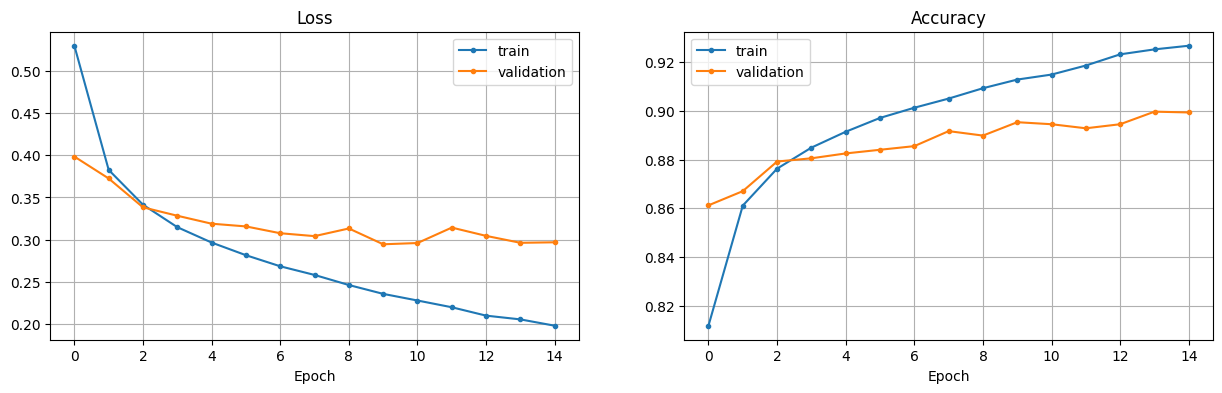

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
train_loader, valid_loader, test_loader = build_loaders(125, True, torch_gen)

final_model = build_rand_search_model(best_hp)          # rebuild fresh from winning HPs
history = final_model.fit(train_loader, validation_data=valid_loader, epochs=50, callbacks=[
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ],
)

Smoothed scores over epochs groupd by folds:
Epoch  1: train_loss=0.5300  val_loss=0.3985  train_acc=0.8117  val_acc=0.8612
Epoch  2: train_loss=0.3827  val_loss=0.3725  train_acc=0.8611  val_acc=0.8670
Epoch  3: train_loss=0.3414  val_loss=0.3383  train_acc=0.8762  val_acc=0.8792
Epoch  4: train_loss=0.3147  val_loss=0.3283  train_acc=0.8849  val_acc=0.8805
Epoch  5: train_loss=0.2965  val_loss=0.3188  train_acc=0.8914  val_acc=0.8825
Epoch  6: train_loss=0.2815  val_loss=0.3156  train_acc=0.8971  val_acc=0.8840
Epoch  7: train_loss=0.2683  val_loss=0.3075  train_acc=0.9013  val_acc=0.8855
Epoch  8: train_loss=0.2580  val_loss=0.3041  train_acc=0.9050  val_acc=0.8917
Epoch  9: train_loss=0.2461  val_loss=0.3132  train_acc=0.9093  val_acc=0.8898
Epoch 10: train_loss=0.2356  val_loss=0.2944  train_acc=0.9129  val_acc=0.8953
Epoch 11: train_loss=0.2277  val_loss=0.2959  train_acc=0.9149  val_acc=0.8945
Epoch 12: train_loss=0.2197  val_loss=0.3142  train_acc=0.9186  val_acc=0.8928
Epoch 1

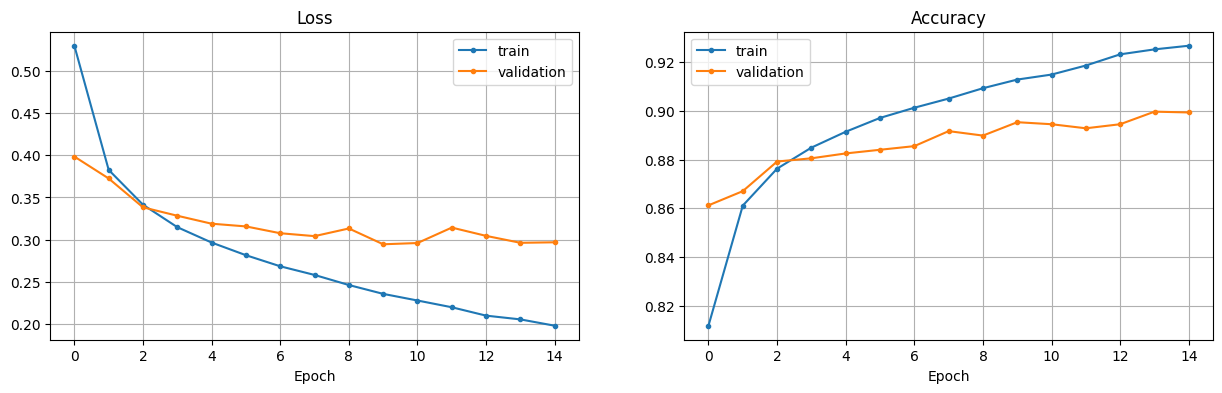

In [45]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["accuracy"], history.history["val_accuracy"])